<a href="https://colab.research.google.com/github/ohood95/ohood95.github.io/blob/master/FERPlus_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QCS — FERPlus-7 Facial Expression Recognition

Cleaned and reorganized notebook. Redundant inspection/debugging cells were removed, while the main reproducible pipeline was kept.

## 1. Environment Setup

In [1]:
from google.colab import files

uploaded = files.upload()

Saving fer2013new.csv to fer2013new.csv
Saving kaggle.json to kaggle (2).json


In [2]:
# ============================================================
# 1. Clone QCS
# ============================================================

%cd /content

!git clone https://github.com/birdwcp/QCS.git

%cd /content/QCS

!ls


# ============================================================
# 2. Install Python 3.10
# ============================================================

!apt-get update -qq
!apt-get install -y python3.10 python3.10-venv python3.10-dev -qq

!python3.10 --version


# ============================================================
# 3. Create isolated virtual environment
# ============================================================

!python3.10 -m venv /content/qcs_env

!/content/qcs_env/bin/python --version

!/content/qcs_env/bin/pip install --upgrade pip setuptools wheel


# ============================================================
# 4. Install PyTorch 1.13.0 + CUDA 11.7
# ============================================================

!/content/qcs_env/bin/pip install -q \
    torch==1.13.0+cu117 \
    torchvision==0.14.0+cu117 \
    --extra-index-url https://download.pytorch.org/whl/cu117


# ============================================================
# 5. Install core QCS dependencies
# ============================================================

!/content/qcs_env/bin/pip install -q \
    timm==0.6.12 \
    easydict==1.13 \
    opencv-python==4.6.0.66 \
    numpy==1.21.6 \
    matplotlib==3.5.3 \
    pandas==1.3.5 \
    scipy==1.7.3 \
    scikit-learn==1.0.2 \
    seaborn==0.12.2


# ============================================================
# 6. Install additional dependencies
# ============================================================

!/content/qcs_env/bin/pip install -q \
    thop==0.1.1.post2209072238 \
    grad-cam==1.4.6 \
    tensorboardX==2.6.2.2 \
    visdom==0.2.4 \
    torchsampler==0.1.2


# ============================================================
# 7. Verify installed versions
# ============================================================

!/content/qcs_env/bin/python -c "import torch; print('PyTorch:', torch.__version__); print('CUDA available:', torch.cuda.is_available())"

!/content/qcs_env/bin/python -c "import torchvision; print('Torchvision:', torchvision.__version__)"

!/content/qcs_env/bin/python -c "import timm; print('timm:', timm.__version__)"

!/content/qcs_env/bin/python -c "import numpy; print('NumPy:', numpy.__version__)"

!/content/qcs_env/bin/python -c "import cv2; print('OpenCV:', cv2.__version__)"

!/content/qcs_env/bin/python -c "import scipy; print('SciPy:', scipy.__version__)"

!/content/qcs_env/bin/python -c "import sklearn; print('Scikit-learn:', sklearn.__version__)"

/content
fatal: destination path 'QCS' already exists and is not an empty directory.
/content/QCS
checkpoint_ferplus  main_DCS_affectnet-7.py  main_QCS_ferplus.py
data_processing     main_DCS_affectnet-8.py  main_QCS_raf_db.py
datas		    main_DCS_ferplus.py      models
fer2013new.csv	    main_DCS_raf_db.py	     __pycache__
fig		    main_QCS_affectnet-7.py  README.md
LICENSE		    main_QCS_affectnet-8.py  requirements.txt
log_ferplus	    main_QCS_ferplus7.py     utils.py
W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Python 3.10.20
Python 3.10.20
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached wheel-0.48.0

In [3]:
!/content/qcs_env/bin/pip install -q "setuptools<70" "wheel<0.42"

In [4]:
!/content/qcs_env/bin/pip install -q "visdom==0.2.4" --no-build-isolation

In [5]:
!/content/qcs_env/bin/python -c "import visdom; print('Visdom:', visdom.__version__)"

Visdom: 0.2.4


In [6]:
# ======================================================================
# QCS Environment Verification
# ======================================================================

import subprocess

result = subprocess.run(
    [
        "/content/qcs_env/bin/python",
        "-c",
        """
import sys
import torch
import torchvision
import timm
import easydict
import cv2
import numpy
import scipy
import sklearn

print("========================================")
print("QCS Environment Verification")
print("========================================")

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("timm:", timm.__version__)
print("NumPy:", numpy.__version__)
print("OpenCV:", cv2.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

print("========================================")
print("QCS environment OK")
print("========================================")
"""
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("ERROR:")
    print(result.stderr)

QCS Environment Verification
Python: 3.10.20
PyTorch: 1.13.0+cu117
Torchvision: 0.14.0+cu117
timm: 0.6.12
NumPy: 1.21.6
OpenCV: 4.6.0
SciPy: 1.7.3
Scikit-learn: 1.0.2
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
CUDA version: 11.7
QCS environment OK



In [7]:
import os

print("fer2013new.csv:")
print(os.path.exists("/content/QCS/fer2013new.csv"))

print("\nkaggle.json:")
print(os.path.exists("/content/kaggle.json"))
print(os.path.exists("/content/QCS/kaggle.json"))

fer2013new.csv:
True

kaggle.json:
True
False


## 2. Dataset Preparation

In [8]:
# ======================================================================
# 1. Check uploaded files
# ======================================================================

import os
import shutil

print("Files in /content:")
print(os.listdir("/content"))

# ======================================================================
# 2. Move fer2013new.csv to QCS
# ======================================================================

if os.path.exists("/content/fer2013new.csv"):
    shutil.move(
        "/content/fer2013new.csv",
        "/content/QCS/fer2013new.csv"
    )
    print("fer2013new.csv moved to QCS.")
elif os.path.exists("/content/QCS/fer2013new.csv"):
    print("fer2013new.csv already exists in QCS.")
else:
    print("ERROR: fer2013new.csv not found.")

# ======================================================================
# 3. Check CSV
# ======================================================================

import pandas as pd

csv_path = "/content/QCS/fer2013new.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    print("\nCSV loaded successfully!")
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())

    display(df.head(3))
else:
    print("ERROR: CSV file is missing.")

# ======================================================================
# 4. Configure Kaggle API
# ======================================================================

os.makedirs("/root/.kaggle", exist_ok=True)

if os.path.exists("/content/kaggle.json"):
    shutil.copy(
        "/content/kaggle.json",
        "/root/.kaggle/kaggle.json"
    )

    os.chmod("/root/.kaggle/kaggle.json", 0o600)

    print("\nKaggle API configured successfully.")
else:
    print("ERROR: kaggle.json not found.")

# ======================================================================
# 5. Download FER2013
# ======================================================================

!kaggle competitions download \
  -c challenges-in-representation-learning-facial-expression-recognition-challenge \
  -f fer2013.tar.gz \
  -p /content

# ======================================================================
# 6. Extract FER2013
# ======================================================================

import tarfile

tar_path = "/content/fer2013.tar.gz"
extract_path = "/content/FER2013"

os.makedirs(extract_path, exist_ok=True)

if os.path.exists(tar_path):
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(extract_path)

    print("\nFER2013 extracted successfully!")
    print("Contents:")
    print(os.listdir(extract_path))
else:
    print("ERROR: fer2013.tar.gz was not downloaded.")

Files in /content:
['.config', 'kaggle (2).json', 'fer2013.tar.gz', 'kaggle.json', 'QCS', 'kaggle (1).json', 'fer2013new.csv', 'FER2013', 'qcs_env', 'sample_data']
fer2013new.csv moved to QCS.

CSV loaded successfully!
Shape: (35887, 12)

Columns:
['Usage', 'Image name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF']


,Usage,Image name,neutral,happiness,surprise,sadness,anger,disgust,fear,contempt,unknown,NF
0,Training,fer0000000.png,4,0,0,1,3,2,0,0,0,0
1,Training,fer0000001.png,6,0,1,1,0,0,0,0,2,0
2,Training,fer0000002.png,5,0,0,3,1,0,0,0,1,0



Kaggle API configured successfully.
fer2013.tar.gz: Skipping, found more recently modified local copy (use --force to force download)


/tmp/ipykernel_18689/2562895391.py:83: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)



FER2013 extracted successfully!
Contents:
['fer2013']


In [9]:
import os
import shutil

# عرض الملفات التي رفعتها
print("Files in /content:")
print(os.listdir("/content"))

# نقل fer2013new.csv إلى QCS
if os.path.exists("/content/fer2013new.csv"):
    shutil.move(
        "/content/fer2013new.csv",
        "/content/QCS/fer2013new.csv"
    )
    print("fer2013new.csv moved to QCS successfully.")
else:
    print("fer2013new.csv not found in /content")

# التحقق
print("\nFinal check:")
print("fer2013new.csv:", os.path.exists("/content/QCS/fer2013new.csv"))
print("kaggle.json:", os.path.exists("/content/kaggle.json"))

Files in /content:
['.config', 'kaggle (2).json', 'fer2013.tar.gz', 'kaggle.json', 'QCS', 'kaggle (1).json', 'FER2013', 'qcs_env', 'sample_data']
fer2013new.csv not found in /content

Final check:
fer2013new.csv: True
kaggle.json: True


In [10]:
import pandas as pd

fer_path = "/content/FER2013/fer2013/fer2013.csv"
fer = pd.read_csv(fer_path)

print("FER2013 shape:", fer.shape)
print("\nColumns:")
print(fer.columns.tolist())

print("\nFER+ shape:", df.shape)

print("\nSame number of rows:", len(fer) == len(df))

# ======================================================================
# Next step

import pandas as pd
import numpy as np
import sys

ferplus_path = "/content/QCS/fer2013new.csv"
df = pd.read_csv(ferplus_path)

emotion_cols = [
    "neutral", "happiness", "surprise", "sadness",
    "anger", "disgust", "fear", "contempt"
]

# نسخ الأصوات حتى لا نغيّر الملف الأصلي
votes = df[emotion_cols].astype(float).copy()

# Microsoft FER+:
# إزالة أي emotion حصلت على صوت واحد فقط
votes[votes < 1.0 + sys.float_info.epsilon] = 0

# مجموع الأصوات بعد إزالة الـ outliers
vote_sum = votes.sum(axis=1)

# أعلى تصويت
max_vote = votes.max(axis=1)

# هل تجاوز أعلى تصويت 50%؟
majority = max_vote > 0.5 * vote_sum

# الـ label الذي حصل على أعلى تصويت
majority_label = votes.idxmax(axis=1)

# عدد العينات حسب النتيجة
print("Total samples:", len(df))
print("\nMajority > 50%:", majority.sum())
print("No clear majority:", (~majority).sum())

print("\nMajority labels:")
print(majority_label[majority].value_counts())

print("\nContempt samples with clear majority:",
      ((majority_label == "contempt") & majority).sum())

# ======================================================================
# Next step

# توزيع FERPlus-7 حسب الـ official FER2013 split

emotion_cols = [
    "neutral", "happiness", "surprise", "sadness",
    "anger", "disgust", "fear", "contempt"
]

votes = df[emotion_cols].astype(float).copy()
votes[votes < 1.0] = 0

vote_sum = votes.sum(axis=1)
max_vote = votes.max(axis=1)

majority = max_vote > 0.5 * vote_sum
majority_label = votes.idxmax(axis=1)

# FERPlus-7 فقط
keep = majority & (majority_label != "contempt")

ferplus7 = df.loc[keep].copy()
ferplus7["label"] = majority_label[keep]

print("Total FERPlus-7:", len(ferplus7))

print("\nSplit distribution:")
print(ferplus7["Usage"].value_counts())

print("\nClass distribution:")
print(ferplus7["label"].value_counts())

# ======================================================================
# Next step

import pandas as pd

fer_path = "/content/FER2013/fer2013/fer2013.csv"
fer = pd.read_csv(fer_path)

print(fer.head(3))
print("\nUsage counts:")
print(fer["Usage"].value_counts())

# ======================================================================
# Next step

import pandas as pd

fer_path = "/content/FER2013/fer2013/fer2013.csv"
fer = pd.read_csv(fer_path)

print(fer.head(3))
print("\nUsage counts:")
print(fer["Usage"].value_counts())

# ======================================================================
# Next step

import pandas as pd
import numpy as np
import sys
from PIL import Image
from pathlib import Path

# Paths
fer_path = "/content/FER2013/fer2013/fer2013.csv"
ferplus_path = "/content/QCS/fer2013new.csv"

fer = pd.read_csv(fer_path)
ferplus = pd.read_csv(ferplus_path)

# FER+ emotion columns
emotion_cols = [
    "neutral", "happiness", "surprise", "sadness",
    "anger", "disgust", "fear", "contempt"
]

# Copy votes
votes = ferplus[emotion_cols].astype(float).copy()

# Microsoft FER+ majority preprocessing:
# Remove emotions with only one vote
votes[votes < 1.0 + sys.float_info.epsilon] = 0

vote_sum = votes.sum(axis=1)
max_vote = votes.max(axis=1)

# Majority > 50%
majority = max_vote > 0.5 * vote_sum

# Majority emotion
majority_label = votes.idxmax(axis=1)

# Keep only 7 desired emotions
keep = majority & (majority_label != "contempt")

# Check alignment
assert len(fer) == len(ferplus)
assert (fer["Usage"].values == ferplus["Usage"].values).all()

# Create final dataframe
data = fer.loc[keep, ["pixels", "Usage"]].copy()
data["emotion"] = majority_label[keep].values
data["original_index"] = np.where(keep)[0]

# 7-class mapping
label_map = {
    "neutral": 0,
    "happiness": 1,
    "surprise": 2,
    "sadness": 3,
    "anger": 4,
    "disgust": 5,
    "fear": 6
}

data["label"] = data["emotion"].map(label_map)

print("FERPlus-7 samples:", len(data))
print("\nClasses:")
print(data["emotion"].value_counts())

print("\nSplits:")
print(data["Usage"].value_counts())

print("\nLabel mapping:")
print(label_map)

FER2013 shape: (35887, 3)

Columns:
['emotion', 'pixels', 'Usage']

FER+ shape: (35887, 12)

Same number of rows: True
Total samples: 35887

Majority > 50%: 32644
No clear majority: 3243

Majority labels:
neutral      11519
happiness     9123
surprise      4079
sadness       4054
anger         2799
fear           715
disgust        183
contempt       172
Name: count, dtype: int64

Contempt samples with clear majority: 172
Total FERPlus-7: 30082

Split distribution:
Usage
Training       23960
PublicTest      3068
PrivateTest     3054
Name: count, dtype: int64

Class distribution:
label
neutral      10677
happiness     8963
surprise      3761
sadness       3624
anger         2406
fear           539
disgust        112
Name: count, dtype: int64
   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 1

In [11]:
from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
import sys

# ============================================================
# Paths
# ============================================================

fer_path = "/content/FER2013/fer2013/fer2013.csv"
ferplus_path = "/content/QCS/fer2013new.csv"

fer = pd.read_csv(fer_path)
ferplus = pd.read_csv(ferplus_path)

# ============================================================
# FERPlus categories
# ============================================================

all_cols = [
    "neutral",
    "happiness",
    "surprise",
    "sadness",
    "anger",
    "disgust",
    "fear",
    "contempt",
    "unknown",
    "NF"
]

seven_classes = [
    "neutral",
    "happiness",
    "surprise",
    "sadness",
    "anger",
    "disgust",
    "fear"
]

# ============================================================
# Step 1: Read all 10 annotator vote categories
# ============================================================

votes = ferplus[all_cols].astype(float).copy()

# Same outlier removal used by official FERPlus majority processing
votes[votes < 1.0 + sys.float_info.epsilon] = 0

# ============================================================
# Step 2: Calculate majority using ALL 10 categories
# ============================================================

vote_sum = votes.sum(axis=1)
max_vote = votes.max(axis=1)

majority = max_vote > 0.5 * vote_sum

majority_label = votes.idxmax(axis=1)

# ============================================================
# Step 3: Keep only the seven required emotions
# ============================================================

keep = majority & majority_label.isin(seven_classes)

# ============================================================
# Label mapping
# ============================================================

label_map = {
    "neutral": 0,
    "happiness": 1,
    "surprise": 2,
    "sadness": 3,
    "anger": 4,
    "disgust": 5,
    "fear": 6
}

# ============================================================
# Create final FERPlus-7 dataframe
# ============================================================

data = fer.loc[keep, ["pixels", "Usage"]].copy()

data["emotion"] = majority_label[keep].values
data["label"] = data["emotion"].map(label_map).astype(int)

print("Final FERPlus-7 samples:", len(data))

# ============================================================
# Create output directories
# ============================================================

output_root = Path("/content/QCS/datas/FERPlus7")
img_dir = output_root / "img"

img_dir.mkdir(parents=True, exist_ok=True)

# Remove previous images
for f in img_dir.glob("*.png"):
    f.unlink()

# ============================================================
# Create PNG images
# ============================================================

for n, (_, row) in enumerate(data.iterrows()):

    pixels = np.fromstring(
        row["pixels"],
        sep=" ",
        dtype=np.uint8
    )

    image = Image.fromarray(
        pixels.reshape(48, 48)
    ).convert("RGB")

    image.save(
        img_dir / f"ferplus7_{n:05d}.png"
    )

# ============================================================
# Create image names
# ============================================================

data["ImageName"] = [
    f"ferplus7_{i:05d}.png"
    for i in range(len(data))
]

# ============================================================
# Save training and test files
# ============================================================

train_data = data[
    data["Usage"] == "Training"
].copy()

test_data = data[
    data["Usage"].isin(["PublicTest", "PrivateTest"])
].copy()

train_file = output_root / "ferplus7_training.txt"
test_file = output_root / "ferplus7_test.txt"

train_data[
    ["ImageName", "label"]
].to_csv(
    train_file,
    sep=" ",
    header=False,
    index=False
)

test_data[
    ["ImageName", "label"]
].to_csv(
    test_file,
    sep=" ",
    header=False,
    index=False
)

# ============================================================
# Verification
# ============================================================

print("\n========================================")
print("FERPlus-7 Dataset")
print("========================================")

print("Total:", len(data))
print("Training:", len(train_data))
print("Test:", len(test_data))

print("\nClass distribution:")
print(data["emotion"].value_counts().sort_index())

print("\nOriginal split distribution:")
print(data["Usage"].value_counts())

print("\nImages created:")
print(len(list(img_dir.glob("*.png"))))

print("\nTraining file:")
print(train_file)

print("\nTest file:")
print(test_file)

Final FERPlus-7 samples: 31264

FERPlus-7 Dataset
Total: 31264
Training: 24941
Test: 6323

Class distribution:
emotion
anger         2660
disgust        161
fear           677
happiness     9045
neutral      11012
sadness       3749
surprise      3960
Name: count, dtype: int64

Original split distribution:
Usage
Training       24941
PublicTest      3186
PrivateTest     3137
Name: count, dtype: int64

Images created:
31264

Training file:
/content/QCS/datas/FERPlus7/ferplus7_training.txt

Test file:
/content/QCS/datas/FERPlus7/ferplus7_test.txt


## 3. QCS FERPlus-7 Adaptation

In [12]:
from pathlib import Path
import shutil

src = Path("/content/QCS/data_processing/dataset_q0.py")
dst = Path("/content/QCS/data_processing/dataset_q0_ferplus7.py")

# Copy the original loader
shutil.copy(src, dst)

print("Created:", dst)

# ======================================================================
# Next step

from pathlib import Path

file_path = Path("/content/QCS/data_processing/dataset_q0_ferplus7.py")

text = file_path.read_text()

old = """    if dataset == 'FERPlus':
        train_root = '../datas/FERPlus/img'
        test_root = '../datas/FERPlus/img'
        train_pd = pd.read_csv("../datas/FERPlus/ferplus_training.txt", sep=" ", header=None,
                               names=['ImageName', 'label'], engine='python')
        test_pd = pd.read_csv("../datas/FERPlus/ferplus_test.txt", sep=" ", header=None,
                              names=['ImageName', 'label'], engine='python')
        cls_num = 8
"""

new = """    if dataset == 'FERPlus':
        train_root = '../datas/FERPlus/img'
        test_root = '../datas/FERPlus/img'
        train_pd = pd.read_csv("../datas/FERPlus/ferplus_training.txt", sep=" ", header=None,
                               names=['ImageName', 'label'], engine='python')
        test_pd = pd.read_csv("../datas/FERPlus/ferplus_test.txt", sep=" ", header=None,
                              names=['ImageName', 'label'], engine='python')
        cls_num = 8

    if dataset == 'FERPlus7':
        train_root = '../datas/FERPlus7/img'
        test_root = '../datas/FERPlus7/img'
        train_pd = pd.read_csv("../datas/FERPlus7/ferplus7_training.txt", sep=" ", header=None,
                               names=['ImageName', 'label'], engine='python')
        test_pd = pd.read_csv("../datas/FERPlus7/ferplus7_test.txt", sep=" ", header=None,
                              names=['ImageName', 'label'], engine='python')
        cls_num = 7
"""

if old not in text:
    raise ValueError("Original FERPlus block was not found.")

text = text.replace(old, new)

file_path.write_text(text)

print("FERPlus7 loader added successfully.")

# ======================================================================
# Next step

from pathlib import Path
import shutil

src = Path("/content/QCS/main_QCS_ferplus.py")
dst = Path("/content/QCS/main_QCS_ferplus7.py")

shutil.copy(src, dst)

print("Created:", dst)

# ======================================================================
# Next step

from pathlib import Path
import shutil

src = Path("/content/QCS/models/QCS_8cls_ferplus.py")
dst = Path("/content/QCS/models/QCS_7cls_ferplus.py")

shutil.copy(src, dst)

print("Created:", dst)

# ======================================================================
# Next step

from pathlib import Path

p = Path("/content/QCS/models/QCS_7cls_ferplus.py")
text = p.read_text()

text = text.replace(
    "self.VIT_base = VisionTransformer(depth=2, drop_ratio=0, embed_dim=embed_dim)",
    "self.VIT_base = VisionTransformer(depth=2, drop_ratio=0, embed_dim=embed_dim, num_classes=num_classes)"
)

text = text.replace(
    "self.VIT_cross = VisionTransformer(depth=1, drop_ratio=0.2, embed_dim=embed_dim)",
    "self.VIT_cross = VisionTransformer(depth=1, drop_ratio=0.2, embed_dim=embed_dim, num_classes=num_classes)"
)

p.write_text(text)

print("Model updated for 7 classes.")

Created: /content/QCS/data_processing/dataset_q0_ferplus7.py
FERPlus7 loader added successfully.
Created: /content/QCS/main_QCS_ferplus7.py
Created: /content/QCS/models/QCS_7cls_ferplus.py
Model updated for 7 classes.


In [13]:
from pathlib import Path

p = Path("/content/QCS/models/QCS_7cls_ferplus.py")
text = p.read_text()

text = text.replace(
    r"r'.\models\pretrain\ir50.pth'",
    "'/content/QCS/models/pretrain/ir50.pth'"
)

p.write_text(text)

print("ir50 path fixed.")

# ======================================================================
# Next step

from pathlib import Path

p = Path("/content/QCS/main_QCS_ferplus7.py")
text = p.read_text()

text = text.replace(
    "from models.QCS_8cls_ferplus import *",
    "from models.QCS_7cls_ferplus import *"
)

text = text.replace(
    "from data_processing.dataset_q0 import Dataset, collate_fn, config",
    "from data_processing.dataset_q0_ferplus7 import Dataset, collate_fn, config"
)

text = text.replace(
    "choices=['RAF-DB', 'AffectNet-7', 'FERPlus', 'AffectNet-8']",
    "choices=['FERPlus7']"
)

text = text.replace(
    "parser.add_argument('--num_classes', type=int, default=8)",
    "parser.add_argument('--num_classes', type=int, default=7)"
)

text = text.replace(
    "labels=[0, 1, 2, 3, 4, 5, 6, 7]",
    "labels=[0, 1, 2, 3, 4, 5, 6]"
)

text = text.replace(
    "ax_ferplus.set_title('FERPlus', fontsize=12)",
    "ax_ferplus.set_title('FERPlus-7', fontsize=12)"
)

p.write_text(text)

print("main_QCS_ferplus7.py updated successfully.")

# ======================================================================
# Next step

from pathlib import Path

p = Path("/content/QCS/main_QCS_ferplus7.py")
text = p.read_text()

text = text.replace(
    "parser.add_argument('--dataset', default='FERPlus', choices=['FERPlus7'])",
    "parser.add_argument('--dataset', default='FERPlus7', choices=['FERPlus7'])"
)

p.write_text(text)

print("Dataset default fixed to FERPlus7.")

# ======================================================================
# Next step

from pathlib import Path

file = Path("/content/QCS/main_QCS_ferplus7.py")

text = file.read_text()

text = text.replace(
    "parser.add_argument('--dataset', default='FERPlus', choices=['FERPlus7'])",
    "parser.add_argument('--dataset', default='FERPlus7', choices=['FERPlus7'])"
)

file.write_text(text)

print("Updated successfully.")

# ======================================================================
# Next step

from pathlib import Path

path = Path("/content/QCS/main_QCS_ferplus7.py")
text = path.read_text()

text = text.replace(
    "parser.add_argument('--dataset', default='FERPlus', choices=['FERPlus7'],",
    "parser.add_argument('--dataset', default='FERPlus7', choices=['FERPlus7'],"
)

path.write_text(text)

print("Dataset default updated to FERPlus7.")

# ======================================================================
# Next step

from pathlib import Path

path = Path("/content/QCS/main_QCS_ferplus7.py")
text = path.read_text()

old = """x_labels_ferplus = ['Neutral', 'Happy', 'Surprise', 'Sad', 'Anger', 'Disgust', 'Fear', 'Contempt']
        y_labels_ferplus = ['Neutral', 'Happy', 'Surprise', 'Sad', 'Anger', 'Disgust', 'Fear', 'Contempt']"""

new = """x_labels_ferplus = ['Neutral', 'Happy', 'Surprise', 'Sad', 'Anger', 'Disgust', 'Fear']
        y_labels_ferplus = ['Neutral', 'Happy', 'Surprise', 'Sad', 'Anger', 'Disgust', 'Fear']"""

if old in text:
    text = text.replace(old, new)
    path.write_text(text)
    print("Confusion matrix labels updated from 8 classes to 7.")
else:
    print("Target 8-class labels were not found. Please inspect the lines around 459.")

# ======================================================================
# Next step

file_path = "/content/QCS/main_QCS_ferplus7.py"

with open(file_path, "r") as f:
    text = f.read()

text = text.replace(
    "D = np.zeros((8, 8), dtype=int)",
    "D = np.zeros((7, 7), dtype=int)"
)

with open(file_path, "w") as f:
    f.write(text)

print("تم التعديل بنجاح")

# ======================================================================
# Next step

file_path = "/content/QCS/main_QCS_ferplus7.py"

with open(file_path, "r") as f:
    lines = f.readlines()

# Python uses zero-based indexing, so line 316 = index 315
start = 315

new_D = [
    "    D = [[0, 0, 0, 0, 0, 0, 0],\n",
    "         [0, 0, 0, 0, 0, 0, 0],\n",
    "         [0, 0, 0, 0, 0, 0, 0],\n",
    "         [0, 0, 0, 0, 0, 0, 0],\n",
    "         [0, 0, 0, 0, 0, 0, 0],\n",
    "         [0, 0, 0, 0, 0, 0, 0],\n",
    "         [0, 0, 0, 0, 0, 0, 0]]\n"
]

# Find where the old D matrix ends
end = start
while end < len(lines):
    if "]]" in lines[end]:
        end += 1
        break
    end += 1

lines[start:end] = new_D

with open(file_path, "w") as f:
    f.writelines(lines)

print("تم تعديل D إلى 7×7 بنجاح.")

ir50 path fixed.
main_QCS_ferplus7.py updated successfully.
Dataset default fixed to FERPlus7.
Updated successfully.
Dataset default updated to FERPlus7.
Confusion matrix labels updated from 8 classes to 7.
تم التعديل بنجاح
تم تعديل D إلى 7×7 بنجاح.


In [14]:
from pathlib import Path

model_file = Path("/content/QCS/models/QCS_8cls_ferplus.py")

text = model_file.read_text()

print(text[:20000])

# ======================================================================
# Next step

from pathlib import Path

model_file = Path("/content/QCS/models/vit_model_8cls.py")
text = model_file.read_text()

print(text[:20000])

# ======================================================================
# Next step

from pathlib import Path

file_path = Path("/content/QCS/main_QCS_ferplus.py")
text = file_path.read_text()

for i, line in enumerate(text.splitlines(), 1):
    if "num_classes" in line or "pyramid_trans_expr" in line or "confusion_matrix" in line:
        print(f"{i}: {line}")

# ======================================================================
# Next step

from pathlib import Path

p = Path("/content/QCS/main_QCS_ferplus7.py")
lines = p.read_text().splitlines()

for i, line in enumerate(lines, 1):
    if any(k in line for k in [
        "QCS_8cls_ferplus",
        "dataset_q0",
        "FERPlus",
        "num_classes",
        "labels=[",
        "confusion_matrix"
    ]):
        print(f"{i}: {line}")

# ======================================================================
# Next step

from pathlib import Path

p = Path("/content/QCS/main_QCS_ferplus7.py")
lines = p.read_text().splitlines()

keywords = [
    "QCS_8cls_ferplus",
    "dataset_q0",
    "FERPlus",
    "num_classes",
    "labels=[",
    "confusion_matrix"
]

for i, line in enumerate(lines, 1):
    if any(k in line for k in keywords):
        print(f"{i}: {line}")

# ======================================================================
# Next step

from pathlib import Path

file = Path("/content/QCS/main_QCS_ferplus7.py")
text = file.read_text()

keywords = [
    "num_classes",
    "cls_num",
    "labels=[",
    "range(8)",
    "range(7)",
    "FERPlus",
    "confusion_matrix",
    "classification_report",
    "CrossEntropyLoss",
    "torch.save",
    "checkpoint",
    "best",
]

lines = text.splitlines()

for i, line in enumerate(lines, start=1):
    if any(k in line for k in keywords):
        print(f"{i}: {line}")

# ======================================================================
# Next step

from pathlib import Path

file = Path("/content/QCS/main_QCS_ferplus7.py")
text = file.read_text()

checks = [
    "from models.QCS_7cls_ferplus import *",
    "from data_processing.dataset_q0_ferplus7 import Dataset, collate_fn, config",
    "default='FERPlus7'",
    "choices=['FERPlus7']",
    "default=7",
    "num_classes=args.num_classes",
    "labels=[0, 1, 2, 3, 4, 5, 6]",
    "FERPlus-7"
]

print("Training configuration check:\n")

for item in checks:
    print(("✓" if item in text else "✗"), item)

# ======================================================================
# Next step

from pathlib import Path
import re

text = Path("/content/QCS/main_QCS_ferplus7.py").read_text()

for line in text.splitlines():
    if "parser.add_argument('--dataset'" in line:
        print(line)

# ======================================================================
# Next step

from pathlib import Path

text = Path("/content/QCS/main_QCS_ferplus7.py").read_text().splitlines()

print("Relevant training lines:\n")

for i, line in enumerate(text, 1):
    if any(keyword in line for keyword in [
        "for epoch",
        "for i, data",
        "loss",
        "label",
        "target",
        "num_classes",
        "val_acc",
        "optimizer",
        "scheduler"
    ]):
        print(f"{i}: {line}")

# ======================================================================
# Next step

from pathlib import Path

text = Path("/content/QCS/main_QCS_ferplus7.py").read_text().splitlines()

print("Training settings:\n")

for i, line in enumerate(text, 1):
    if any(x in line for x in [
        "'--epochs'",
        "'--batch_size'",
        "'--lr'",
        "'--workers'",
        "'--checkpoint_path'",
        "'--best_checkpoint_path'",
        "'--resume'",
        "'--evaluate'",
        "'--optimizer'"
    ]):
        print(f"{i}: {line}")

# ======================================================================
# Next step

from pathlib import Path

text = Path("/content/QCS/main_QCS_ferplus7.py").read_text().splitlines()

for i, line in enumerate(text, 1):
    if "batch" in line.lower():
        print(f"{i}: {line}")

import torch
import torch.nn as nn
from torch.nn import functional as F
from .ir50 import Backbone
from .vit_model_8cls import VisionTransformer, PatchEmbed
from timm.models.layers import trunc_normal_, DropPath
from thop import profile
from utils import *


def load_pretrained_weights(model, checkpoint):
    import collections
    if 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint
    model_dict = model.state_dict()
    new_state_dict = collections.OrderedDict()
    matched_layers, discarded_layers = [], []
    for k, v in state_dict.items():
        # If the pretrained state_dict was saved as nn.DataParallel,
        # keys would contain "module.", which should be ignored.
        if k.startswith('module.'):
            k = k[7:]
        if k.startswith('ir_back.'):
            k = k[8:]
        if k in model_dict and model_dict[k].size() == v.size():
            new_state_dict[k] = v
            matched_layers.appen

## 4. Pretrained Weights and Validation

In [15]:
from pathlib import Path

root = Path("/content/QCS")

matches = list(root.rglob("ir50.pth"))

print("Found:", len(matches))

for p in matches:
    print(p)

# ======================================================================
# Next step

from pathlib import Path

models_dir = Path("/content/QCS/models")

for p in models_dir.rglob("*"):
    if p.is_file() and ("pretrain" in str(p).lower() or p.suffix in [".pth", ".pt"]):
        print(p)

# ======================================================================
# Next step

from pathlib import Path

root = Path("/content/QCS")

for p in root.rglob("*.py"):
    text = p.read_text(errors="ignore")
    if "ir50.pth" in text:
        print(f"\n--- {p} ---")
        for i, line in enumerate(text.splitlines(), 1):
            if "ir50.pth" in line or "ir50" in line.lower():
                print(f"{i}: {line}")

# ======================================================================
# Next step

from pathlib import Path

root = Path("/content/QCS")

for p in root.rglob("*"):
    if p.is_file() and p.suffix.lower() in [".md", ".txt", ".py", ".json", ".yml", ".yaml"]:
        text = p.read_text(errors="ignore")
        if "ir50" in text.lower():
            print(f"\n--- {p} ---")
            for i, line in enumerate(text.splitlines(), 1):
                if "ir50" in line.lower() or "pretrain" in line.lower():
                    print(f"{i}: {line}")

# ======================================================================
# Next step

!pip -q install gdown
!gdown 1FV8kUSeVbZ815iWt-YIYiQrCDChrhO2G \
  -O /content/QCS/models/pretrain/ir50.pth

Found: 1
/content/QCS/models/pretrain/ir50.pth
/content/QCS/models/pretrain/ir50.pth
/content/QCS/models/pretrain/save_pretrain_here

--- /content/QCS/models/DCS_8cls_affectnet.py ---
4: from .ir50 import Backbone
142:         ir_checkpoint = torch.load(r'.\models\pretrain\ir50.pth', map_location=lambda storage, loc: storage)

--- /content/QCS/models/QCS_8cls_ferplus.py ---
4: from .ir50 import Backbone
178:         ir_checkpoint = torch.load(r'.\models\pretrain\ir50.pth', map_location=lambda storage, loc: storage)

--- /content/QCS/models/QCS_7cls_affectnet.py ---
4: from .ir50 import Backbone
182:         ir_checkpoint = torch.load(r'.\models\pretrain\ir50.pth', map_location=lambda storage, loc: storage)

--- /content/QCS/models/DCS_8cls_ferplus.py ---
4: from .ir50 import Backbone
143:         ir_checkpoint = torch.load(r'.\models\pretrain\ir50.pth', map_location=lambda storage, loc: storage)

--- /content/QCS/models/DCS_7cls_raf_db.py ---
4: from .ir50 import Backbone
145:         

In [16]:
import subprocess

code = r'''
import sys

sys.path.insert(0, "/content/QCS")

from data_processing.dataset_q0_ferplus7 import Dataset, collate_fn, config

train_root, test_root, train_pd, test_pd, cls_num = config(dataset="FERPlus7")

print("Train samples:", len(train_pd))
print("Test samples:", len(test_pd))
print("Number of classes:", cls_num)

train_dataset = Dataset(
    train_root,
    train_pd,
    train=True,
    transform=None,
    num_positive=1,
    num_negative=1
)

print("Dataset length:", len(train_dataset))

sample = train_dataset[0]

print("Sample type:", type(sample))
print("Sample length:", len(sample))

for i, item in enumerate(sample):
    if hasattr(item, "shape"):
        print(f"Item {i} shape:", item.shape)
    else:
        print(f"Item {i}:", item)
'''

result = subprocess.run(
    ["/content/qcs_env/bin/python", "-c", code],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

# ======================================================================
# Next step

import subprocess

code = r'''
import sys
sys.path.insert(0, "/content/QCS")

from data_processing.dataset_q0_ferplus7 import Dataset, collate_fn, config

train_root, test_root, train_pd, test_pd, cls_num = config(dataset="FERPlus7")

print("Train samples:", len(train_pd))
print("Test samples:", len(test_pd))
print("Number of classes:", cls_num)

train_dataset = Dataset(
    train_root,
    train_pd,
    train=True,
    transform=None,
    num_positive=1,
    num_negative=1
)

print("Dataset length:", len(train_dataset))

sample = train_dataset[0]

print("Sample type:", type(sample))
print("Sample length:", len(sample))

for i, item in enumerate(sample):
    if hasattr(item, "shape"):
        print(f"Item {i} shape:", item.shape)
    else:
        print(f"Item {i}:", item)
'''

result = subprocess.run(
    ["/content/qcs_env/bin/python", "-c", code],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

# ======================================================================
# Next step

from pathlib import Path

file = Path("/content/QCS/data_processing/dataset_q0_ferplus7.py")

text = file.read_text()

text = text.replace(
    "train_root = '../datas/FERPlus7/img'",
    "train_root = '/content/QCS/datas/FERPlus7/img'"
)

text = text.replace(
    "test_root = '../datas/FERPlus7/img'",
    "test_root = '/content/QCS/datas/FERPlus7/img'"
)

text = text.replace(
    '"../datas/FERPlus7/ferplus7_training.txt"',
    '"/content/QCS/datas/FERPlus7/ferplus7_training.txt"'
)

text = text.replace(
    '"../datas/FERPlus7/ferplus7_test.txt"',
    '"/content/QCS/datas/FERPlus7/ferplus7_test.txt"'
)

file.write_text(text)

print("Updated:", file)
print()
print("FERPlus7 paths:")
for line in text.splitlines():
    if "FERPlus7" in line:
        print(line)

# ======================================================================
# Next step

import subprocess

code = r'''
import sys
sys.path.insert(0, "/content/QCS")

from data_processing.dataset_q0_ferplus7 import Dataset, config

train_root, test_root, train_pd, test_pd, cls_num = config(dataset="FERPlus7")

print("Train samples:", len(train_pd))
print("Test samples:", len(test_pd))
print("Number of classes:", cls_num)

train_dataset = Dataset(
    train_root,
    train_pd,
    train=True,
    transform=None,
    num_positive=1,
    num_negative=1
)

print("Dataset length:", len(train_dataset))

sample = train_dataset[0]

print("Sample type:", type(sample))
print("Sample length:", len(sample))

for i, item in enumerate(sample):
    if hasattr(item, "shape"):
        print(f"Item {i} shape:", item.shape)
    else:
        print(f"Item {i}:", item)
'''

result = subprocess.run(
    ["/content/qcs_env/bin/python", "-c", code],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

# ======================================================================
# Next step

import subprocess

code = r'''
import sys
sys.path.insert(0, "/content/QCS")

from torchvision import transforms
from data_processing.dataset_q0_ferplus7 import Dataset, config

train_root, test_root, train_pd, test_pd, cls_num = config(dataset="FERPlus7")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = Dataset(
    train_root,
    train_pd,
    train=True,
    transform=train_transform,
    num_positive=1,
    num_negative=1
)

sample = train_dataset[0]

print("Dataset length:", len(train_dataset))
print("Sample length:", len(sample))

for i, item in enumerate(sample):
    if hasattr(item, "shape"):
        print(f"Item {i} shape:", item.shape)
    else:
        print(f"Item {i}:", item)
'''

result = subprocess.run(
    ["/content/qcs_env/bin/python", "-c", code],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

# ======================================================================
# Next step

import subprocess

code = r'''
import sys
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

sys.path.insert(0, "/content/QCS")

from data_processing.dataset_q0_ferplus7 import Dataset, collate_fn, config
from models.QCS_7cls_ferplus import pyramid_trans_expr

train_root, test_root, train_pd, test_pd, cls_num = config(dataset="FERPlus7")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = Dataset(
    train_root,
    train_pd,
    train=True,
    transform=transform,
    num_positive=1,
    num_negative=1
)

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

batch = next(iter(loader))

print("Number of batch elements:", len(batch))

for i, item in enumerate(batch):
    if torch.is_tensor(item):
        print(f"Batch item {i}:", item.shape)
    elif isinstance(item, (list, tuple)):
        print(f"Batch item {i}: type={type(item)}, length={len(item)}")
        if len(item) > 0 and torch.is_tensor(item[0]):
            print(f"  First tensor shape: {item[0].shape}")
    else:
        print(f"Batch item {i}: {type(item)}")

model = pyramid_trans_expr(
    img_size=224,
    num_classes=7
)

model.eval()

with torch.no_grad():
    outputs = model(
        batch[0],
        batch[1][0],
        batch[2][0],
        batch[3][0]
    )

print("Number of model outputs:", len(outputs))

for i, output in enumerate(outputs):
    if torch.is_tensor(output):
        print(f"Output {i}:", output.shape)
    else:
        print(f"Output {i}: {type(output)}")
'''

result = subprocess.run(
    ["/content/qcs_env/bin/python", "-c", code],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

# ======================================================================
# Next step

import subprocess

code = r'''
import sys
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

sys.path.insert(0, "/content/QCS")

from data_processing.dataset_q0_ferplus7 import Dataset, collate_fn, config
from models.QCS_7cls_ferplus import pyramid_trans_expr

train_root, test_root, train_pd, test_pd, cls_num = config(dataset="FERPlus7")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = Dataset(
    train_root,
    train_pd,
    train=True,
    transform=transform,
    num_positive=1,
    num_negative=1
)

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

batch = next(iter(loader))

print("Input shapes:")
for i in range(4):
    print(f"batch[{i}]:", batch[i].shape)

model = pyramid_trans_expr(
    img_size=224,
    num_classes=7
)

model.eval()

with torch.no_grad():
    outputs = model(
        batch[0],
        batch[1],
        batch[2],
        batch[3]
    )

print("\nNumber of model outputs:", len(outputs))

for i, output in enumerate(outputs):
    if torch.is_tensor(output):
        print(f"Output {i}:", output.shape)
    else:
        print(f"Output {i}: {type(output)}")
'''

result = subprocess.run(
    ["/content/qcs_env/bin/python", "-c", code],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

# ======================================================================
# Next step

import subprocess

code = r'''
import sys
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

sys.path.insert(0, "/content/QCS")

from data_processing.dataset_q0_ferplus7 import Dataset, collate_fn, config
from models.QCS_7cls_ferplus import pyramid_trans_expr

train_root, test_root, train_pd, test_pd, cls_num = config(dataset="FERPlus7")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = Dataset(
    train_root,
    train_pd,
    train=True,
    transform=transform,
    num_positive=1,
    num_negative=1
)

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

batch = next(iter(loader))

model = pyramid_trans_expr(
    img_size=224,
    num_classes=7
)

model.train()

outputs = model(
    batch[0],
    batch[1],
    batch[2],
    batch[3]
)

labels = batch[4]

print("Labels:", labels)
print("Label type:", type(labels))

if torch.is_tensor(labels):
    print("Labels shape:", labels.shape)
    print("Labels min:", labels.min().item())
    print("Labels max:", labels.max().item())

criterion = torch.nn.CrossEntropyLoss()

losses = []

for i in range(8):
    loss = criterion(outputs[i], labels)
    losses.append(loss)

    print(f"Loss {i}: {loss.item():.6f}")

total_loss = sum(losses)

print("Total loss:", total_loss.item())
print("Loss is finite:", torch.isfinite(total_loss).item())
'''

result = subprocess.run(
    ["/content/qcs_env/bin/python", "-c", code],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

# ======================================================================
# Next step

import subprocess

code = r'''
import sys
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

sys.path.insert(0, "/content/QCS")

from data_processing.dataset_q0_ferplus7 import Dataset, collate_fn, config
from models.QCS_7cls_ferplus import pyramid_trans_expr

train_root, test_root, train_pd, test_pd, cls_num = config(dataset="FERPlus7")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = Dataset(
    train_root,
    train_pd,
    train=True,
    transform=transform,
    num_positive=1,
    num_negative=1
)

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

batch = next(iter(loader))

model = pyramid_trans_expr(
    img_size=224,
    num_classes=7
)

model.train()

outputs = model(
    batch[0],
    batch[1],
    batch[2],
    batch[3]
)

labels = torch.tensor(batch[4], dtype=torch.long)

print("Labels:", labels)
print("Labels shape:", labels.shape)
print("Labels min:", labels.min().item())
print("Labels max:", labels.max().item())

criterion = torch.nn.CrossEntropyLoss()

losses = []

for i in range(8):
    loss = criterion(outputs[i], labels)
    losses.append(loss)
    print(f"Loss {i}: {loss.item():.6f}")

total_loss = sum(losses)

print("Total loss:", total_loss.item())
print("Loss is finite:", torch.isfinite(total_loss).item())
'''

result = subprocess.run(
    ["/content/qcs_env/bin/python", "-c", code],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

# ======================================================================
# Next step

import subprocess

code = r'''
import sys
sys.path.insert(0, "/content/QCS")

try:
    import main_QCS_ferplus7
    print("Training script import: OK")
except Exception as e:
    print("Training script import: FAILED")
    print(type(e).__name__, ":", e)
'''

result = subprocess.run(
    ["/content/qcs_env/bin/python", "-c", code],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

# ======================================================================
# Next step

import subprocess

code = r'''
import sys
sys.path.insert(0, "/content/QCS")

try:
    import main_QCS_ferplus7
    print("Training script import: OK")
except Exception as e:
    print("Training script import: FAILED")
    print(type(e).__name__, ":", e)
'''

result = subprocess.run(
    ["/content/qcs_env/bin/python", "-c", code],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

# ======================================================================
# Next step

import subprocess

code = r'''
import sys
sys.path.insert(0, "/content/QCS")

try:
    import main_QCS_ferplus7
    print("Training script import: OK")
except Exception as e:
    print("Training script import: FAILED")
    print(type(e).__name__, ":", e)
'''

result = subprocess.run(
    ["/content/qcs_env/bin/python", "-c", code],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

# ======================================================================
# Next step

import subprocess

code = r'''
import sys
import torch

sys.path.insert(0, "/content/QCS")

print("BEFORE IMPORT")
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.device_count())

from models.QCS_7cls_ferplus import *
print("\nAFTER MODEL IMPORT")
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.device_count())

from data_processing.dataset_q0_ferplus7 import Dataset, collate_fn, config
print("\nAFTER DATASET IMPORT")
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.device_count())

import main_QCS_ferplus7
print("\nAFTER MAIN IMPORT")
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.device_count())
'''

result = subprocess.run(
    ["/content/qcs_env/bin/python", "-c", code],
    capture_output=True,
    text=True
)

print(result.stdout)
print("\n===== STDERR =====")
print(result.stderr)

# ======================================================================
# Next step

import subprocess

code = r'''
import sys
import torch

sys.path.insert(0, "/content/QCS")

from models.QCS_7cls_ferplus import pyramid_trans_expr

print("Before model creation:")
print("Python:", sys.executable)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.device_count())

model = pyramid_trans_expr(
    img_size=224,
    num_classes=7
)

print("\nAfter model creation:")
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.device_count())

print("\nTrying model.cuda()...")
model = model.cuda()

print("model.cuda(): OK")
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.device_count())

print("\nTrying DataParallel...")
model = torch.nn.DataParallel(model).cuda()

print("DataParallel: OK")
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.device_count())
'''

result = subprocess.run(
    ["/content/qcs_env/bin/python", "-c", code],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("\n===== STDERR =====")
    print(result.stderr)

# ======================================================================
# Next step

from pathlib import Path

lines = Path("/content/QCS/main_QCS_ferplus7.py").read_text().splitlines()

for i in range(60, 115):
    print(f"{i+1}: {lines[i]}")

# ======================================================================
# Next step

from pathlib import Path

lines = Path("/content/QCS/main_QCS_ferplus7.py").read_text().splitlines()

for i in range(30, 63):
    print(f"{i+1}: {lines[i]}")


STDERR:
Traceback (most recent call last):
  File "<string>", line 8, in <module>
  File "/content/QCS/data_processing/dataset_q0_ferplus7.py", line 49, in config
    train_pd = pd.read_csv("../datas/FERPlus7/ferplus7_training.txt", sep=" ", header=None,
  File "/content/qcs_env/lib/python3.10/site-packages/pandas/util/_decorators.py", line 311, in wrapper
    return func(*args, **kwargs)
  File "/content/qcs_env/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 586, in read_csv
    return _read(filepath_or_buffer, kwds)
  File "/content/qcs_env/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 482, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
  File "/content/qcs_env/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 811, in __init__
    self._engine = self._make_engine(self.engine)
  File "/content/qcs_env/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 1040, in _make_engine
    return mapping[engine](s

## 5. Training

In [17]:
import subprocess

code = r'''
import torch
print("PyTorch version:", torch.__version__)
print("CUDA compiled:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
'''

result = subprocess.run(
    ["/content/qcs_env/bin/python", "-c", code],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

# ======================================================================
# Next step

import sys
import os
import torch

print("Python:", sys.executable)
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Test actual CUDA tensor
x = torch.randn(2, 3).cuda()
print("CUDA tensor test: OK")
print("Tensor device:", x.device)

# ======================================================================
# Next step

import os

os.makedirs("/content/QCS/log_ferplus", exist_ok=True)
os.makedirs("/content/QCS/checkpoint_ferplus", exist_ok=True)

print("log_ferplus:", os.path.exists("/content/QCS/log_ferplus"))
print("checkpoint_ferplus:", os.path.exists("/content/QCS/checkpoint_ferplus"))

PyTorch version: 1.13.0+cu117
CUDA compiled: 11.7
CUDA available: True
GPU count: 1
GPU: NVIDIA A100-SXM4-40GB


Python: /usr/bin/python3
CUDA_VISIBLE_DEVICES: None
PyTorch: 2.11.0+cu128
CUDA available: True
GPU count: 1
GPU: NVIDIA A100-SXM4-40GB
CUDA tensor test: OK
Tensor device: cuda:0
log_ferplus: True
checkpoint_ferplus: True


In [18]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No CUDA GPU available!")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU count: 1
GPU: NVIDIA A100-SXM4-40GB


In [19]:
import subprocess
import os

# ============================================================
# Directories
# ============================================================

os.makedirs("/content/QCS/log_ferplus", exist_ok=True)
os.makedirs("/content/QCS/checkpoint_ferplus", exist_ok=True)

# ============================================================
# QCS FERPlus-7 Training
# ============================================================

cmd = [
    "/content/qcs_env/bin/python",
    "/content/QCS/main_QCS_ferplus7.py",

    "--dataset", "FERPlus7",
    "--num_classes", "7",
    "--gpu", "0",

    "--epochs", "1",
    "--batch-size", "24",
    "--workers", "4",
    "--optimizer", "adam",
    "--lr", "0.0000035"
]

# ============================================================
# Force GPU 0
# ============================================================

env = os.environ.copy()
env["CUDA_VISIBLE_DEVICES"] = "0"

# ============================================================
# Run training ONCE
# ============================================================

print("Starting QCS FERPlus-7 training...")
print("Dataset: FERPlus7")
print("Classes: 7")
print("Epochs: 1")
print("Batch size: 24")
print("Learning rate: 3.5e-6")
print("GPU: 0")
print("=" * 60)

result = subprocess.run(
    cmd,
    cwd="/content/QCS",
    env=env,
    text=True
)

# ============================================================
# Result
# ============================================================

print("\n" + "=" * 60)
print("TRAINING FINISHED")
print("=" * 60)

print("Return code:", result.returncode)

if result.returncode == 0:
    print("Training completed successfully.")
else:
    print("Training failed. Check the error message above.")

Starting QCS FERPlus-7 training...
Dataset: FERPlus7
Classes: 7
Epochs: 1
Batch size: 24
Learning rate: 3.5e-6
GPU: 0

TRAINING FINISHED
Return code: 0
Training completed successfully.


### Final Training — 150 Epochs

In [20]:
!/content/qcs_env/bin/pip install -q "thop==0.1.1.post2209072238"

In [21]:
!CUDA_VISIBLE_DEVICES=0 /content/qcs_env/bin/python /content/QCS/main_QCS_ferplus7.py \
    --dataset FERPlus7 \
    --num_classes 7 \
    --gpu 0 \
    --epochs 100 \
    --batch-size 24 \
    --workers 4 \
    --optimizer adam \
    --lr 0.0000035

Training time: 09-14 20:04
load_weight 304
Current learning rate:  3.5e-06
Epoch: [0][   0/1040]	Loss 2.26176 (2.10049)	Accuracy  0.000 (20.833)	Loss_1 2.33214 (2.33214)	Loss_2 2.34390 (2.34390)	Loss_3 2.21598 (2.21598)	Loss_4 2.21716 (2.21716)	k1 -0.00000 (-0.00000)	k2 0.00000 (0.00000)	k3 -0.00000 (-0.00000)
Epoch: [0][ 100/1040]	Loss 1.65564 (1.67068)	Accuracy 58.333 (35.355)	Loss_1 1.37175 (1.66142)	Loss_2 1.43123 (1.66514)	Loss_3 1.38130 (1.69560)	Loss_4 1.45865 (1.70128)	k1 0.00003 (0.00004)	k2 -0.00007 (-0.00006)	k3 0.00001 (0.00001)
Epoch: [0][ 200/1040]	Loss 1.07052 (1.44545)	Accuracy 66.667 (47.865)	Loss_1 0.98366 (1.44907)	Loss_2 0.69292 (1.44144)	Loss_3 1.02592 (1.50149)	Loss_4 0.80155 (1.50010)	k1 -0.00001 (0.00003)	k2 0.00006 (-0.00004)	k3 0.00038 (0.00010)
Epoch: [0][ 300/1040]	Loss 0.79275 (1.26115)	Accuracy 83.333 (56.236)	Loss_1 0.75494 (1.27332)	Loss_2 0.72447 (1.27336)	Loss_3 0.79427 (1.32248)	Loss_4 0.73770 (1.32818)	k1 -0.00002 (0.00001)	k2 0.00018 (0.00002)	k3 0.

In [22]:
import numpy as np
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# Best Confusion Matrix
# ============================================================

cm = np.array([
    [2099, 47, 17, 98, 10, 1, 0],
    [28, 1702, 20, 6, 2, 0, 0],
    [26, 15, 755, 0, 7, 0, 8],
    [99, 6, 1, 611, 11, 2, 5],
    [26, 17, 6, 11, 493, 3, 4],
    [1, 0, 1, 2, 11, 27, 0],
    [5, 0, 28, 12, 3, 1, 96]
])

class_names = [
    "Neutral",
    "Happiness",
    "Surprise",
    "Sadness",
    "Anger",
    "Disgust",
    "Fear"
]

# ============================================================
# Convert confusion matrix to y_true / y_pred
# ============================================================

y_true = []
y_pred = []

for true_class in range(len(class_names)):
    for predicted_class in range(len(class_names)):
        count = cm[true_class, predicted_class]

        y_true.extend([true_class] * count)
        y_pred.extend([predicted_class] * count)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ============================================================
# Calculate metrics
# ============================================================

accuracy = np.mean(y_true == y_pred)

precision_macro = precision_score(
    y_true, y_pred, average="macro", zero_division=0
)

recall_macro = recall_score(
    y_true, y_pred, average="macro", zero_division=0
)

f1_macro = f1_score(
    y_true, y_pred, average="macro", zero_division=0
)

f1_weighted = f1_score(
    y_true, y_pred, average="weighted", zero_division=0
)

# ============================================================
# Print Overall Results
# ============================================================

print("=" * 75)
print("QCS FERPlus-7 - EVALUATION REPORT")
print("=" * 75)

print(f"\nAccuracy        : {accuracy * 100:.4f}%")
print(f"Macro Precision : {precision_macro * 100:.4f}%")
print(f"Macro Recall    : {recall_macro * 100:.4f}%")
print(f"Macro F1-score  : {f1_macro * 100:.4f}%")
print(f"Weighted F1     : {f1_weighted * 100:.4f}%")

# ============================================================
# Classification Report
# ============================================================

print("\n" + "=" * 75)
print("CLASSIFICATION REPORT")
print("=" * 75)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# Confusion Matrix
# ============================================================

print("=" * 75)
print("CONFUSION MATRIX")
print("=" * 75)

print("Rows    = True labels")
print("Columns = Predicted labels\n")

print("             " + " ".join(f"{name:>11}" for name in class_names))

for i, row in enumerate(cm):
    print(f"{class_names[i]:>11} " + " ".join(f"{x:11d}" for x in row))

print("\n" + "=" * 75)

QCS FERPlus-7 - EVALUATION REPORT

Accuracy        : 91.4598%
Macro Precision : 88.1527%
Macro Recall    : 83.4218%
Macro F1-score  : 85.4992%
Weighted F1     : 91.3922%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Neutral     0.9190    0.9239    0.9214      2272
   Happiness     0.9524    0.9681    0.9602      1758
    Surprise     0.9118    0.9309    0.9213       811
     Sadness     0.8257    0.8313    0.8285       735
       Anger     0.9181    0.8804    0.8988       560
     Disgust     0.7941    0.6429    0.7105        42
        Fear     0.8496    0.6621    0.7442       145

    accuracy                         0.9146      6323
   macro avg     0.8815    0.8342    0.8550      6323
weighted avg     0.9140    0.9146    0.9139      6323

CONFUSION MATRIX
Rows    = True labels
Columns = Predicted labels

                 Neutral   Happiness    Surprise     Sadness       Anger     Disgust        Fear
    Neutral        2099          47          1



QCS FERPlus-7 - COMPLETE EVALUATION REPORT

DATASET STATISTICS
------------------------------------------------------------------------------------------
Number of classes     : 7
Total samples         : 6,323
Correct predictions   : 5,783
Incorrect predictions : 540
Error rate            : 8.5402%

OVERALL PERFORMANCE
------------------------------------------------------------------------------------------
Accuracy              : 91.4598%
Balanced Accuracy     : 83.4218%
Macro Precision       : 88.1527%
Weighted Precision    : 91.4024%
Macro Recall          : 83.4218%
Weighted Recall       : 91.4598%
Macro F1-score        : 85.4992%
Weighted F1-score     : 91.3922%

CLASSIFICATION REPORT
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

     Neutral     0.9190    0.9239    0.9214      2272
   Happiness     0.9524    0.9681    0.9602      1758
    Surprise     0.9118    0.9309    0.9213  

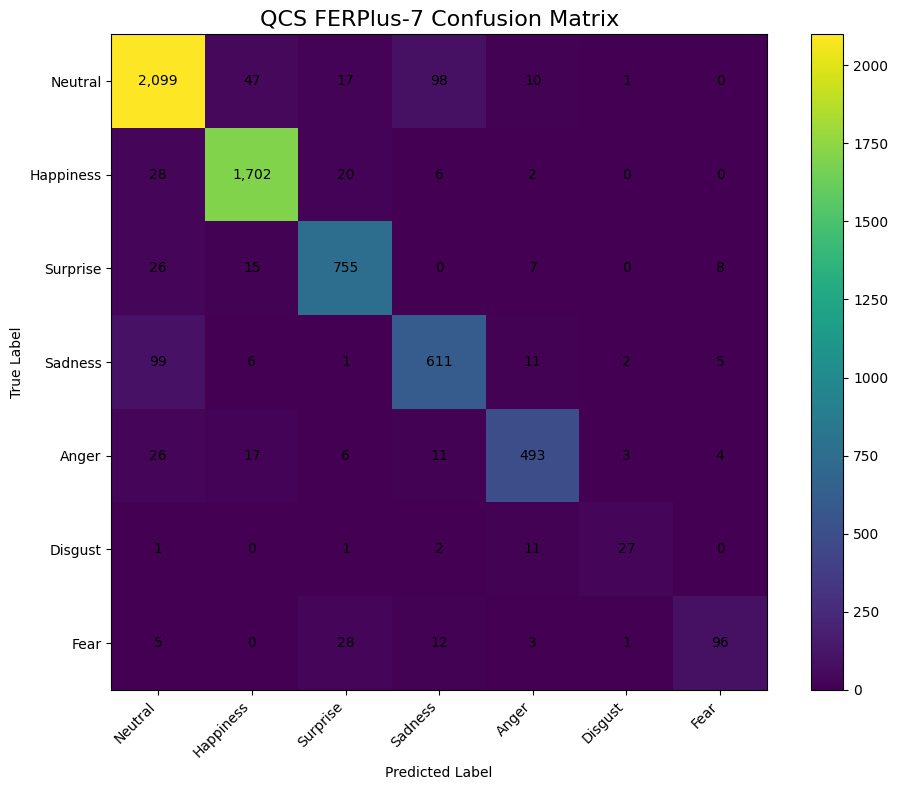

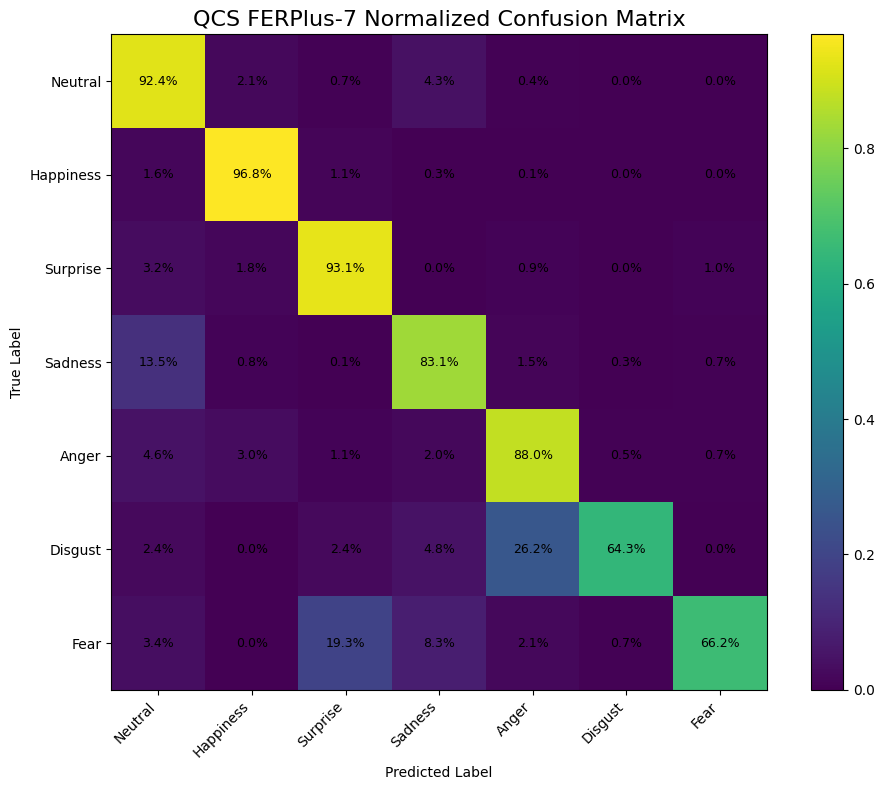

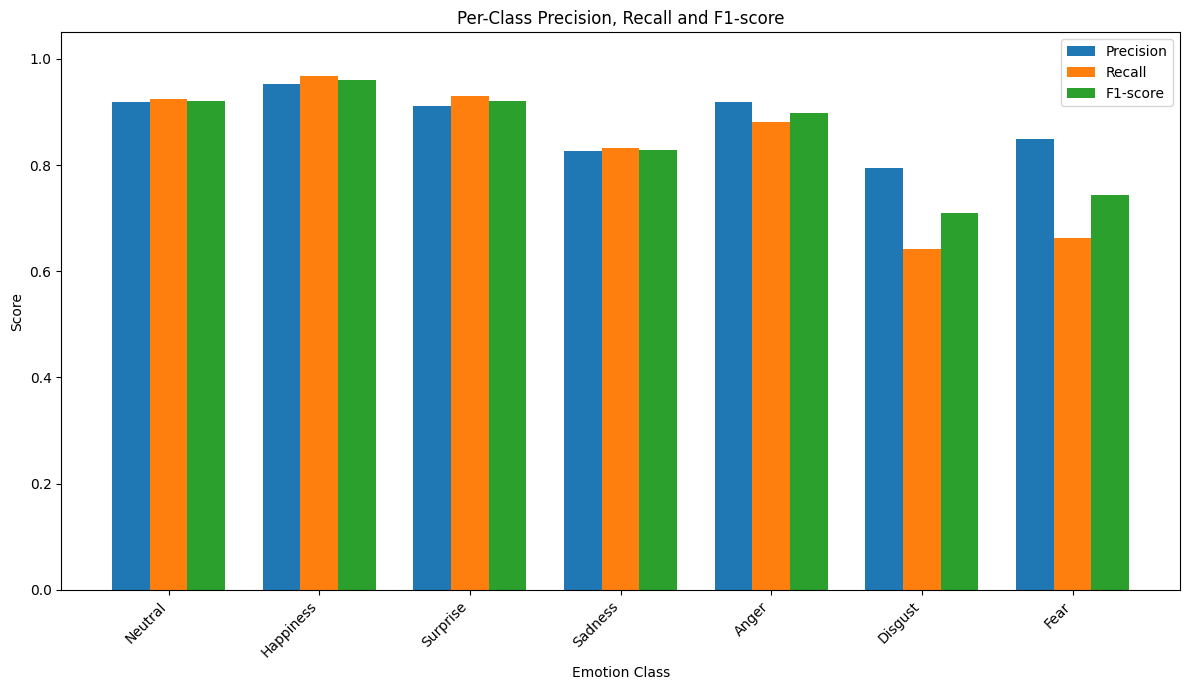

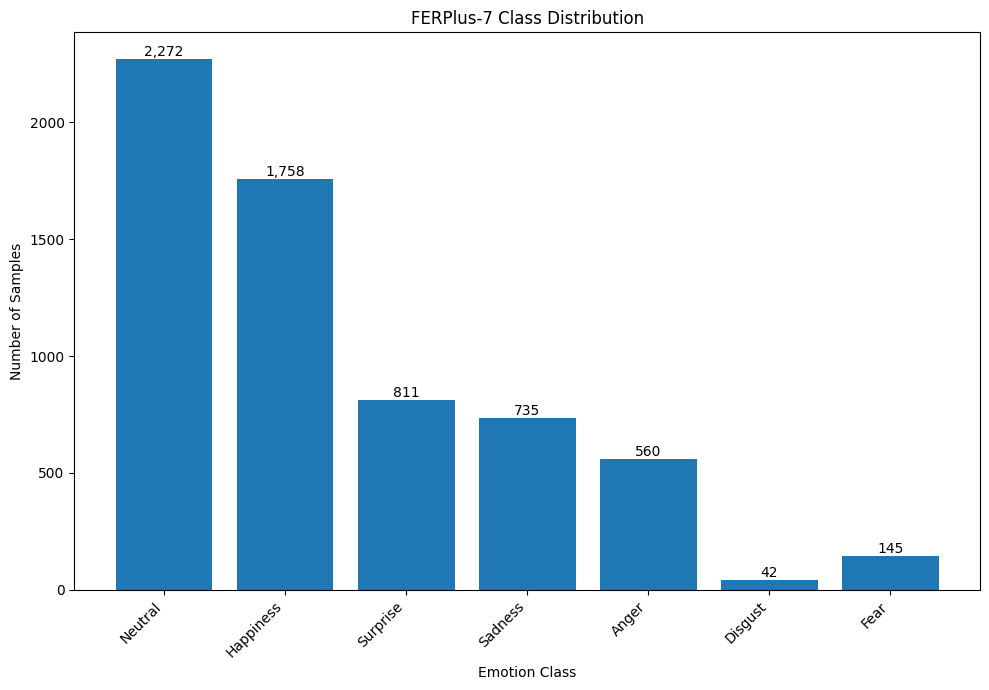

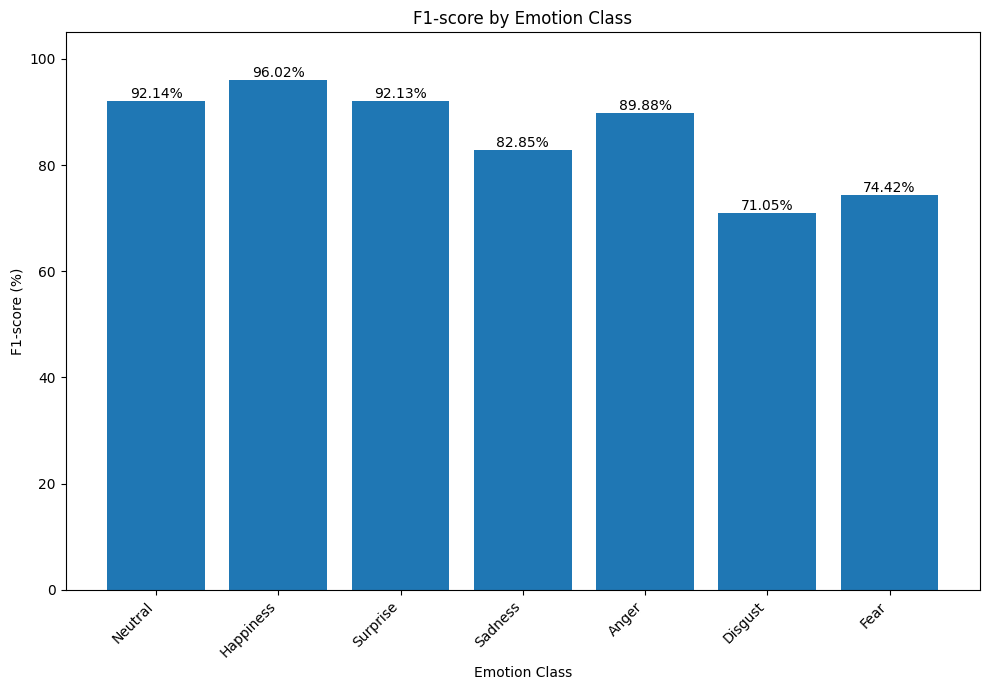

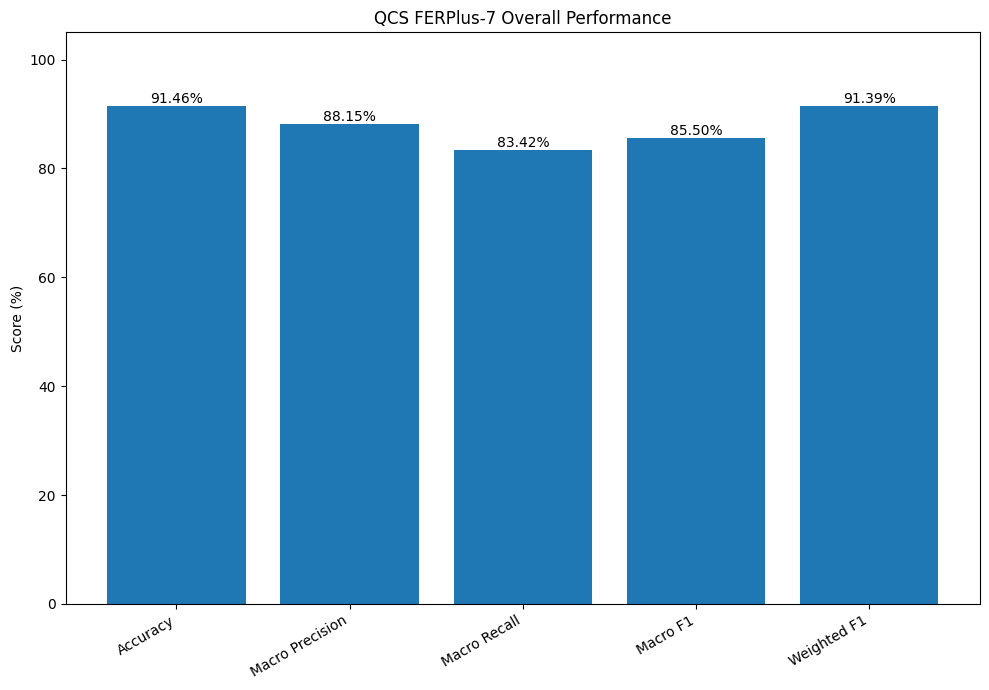


MOST COMMON MISCLASSIFICATIONS
 1. Sadness -> Neutral: 99 samples
 2. Neutral -> Sadness: 98 samples
 3. Neutral -> Happiness: 47 samples
 4. Happiness -> Neutral: 28 samples
 5. Fear -> Surprise: 28 samples
 6. Surprise -> Neutral: 26 samples
 7. Anger -> Neutral: 26 samples
 8. Happiness -> Surprise: 20 samples
 9. Neutral -> Surprise: 17 samples
10. Anger -> Happiness: 17 samples

FINAL SUMMARY
Total Samples       : 6,323
Accuracy            : 91.4598%
Macro Precision     : 88.1527%
Macro Recall        : 83.4218%
Macro F1-score      : 85.4992%
Weighted F1-score   : 91.3922%
Balanced Accuracy   : 83.4218%

Best F1 class       : Happiness (96.02%)
Lowest F1 class     : Disgust (71.05%)

ALL RESULTS SAVED TO:
/content/QCS/QCS_results


In [23]:
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix
)

# ============================================================
# 1. CREATE RESULTS DIRECTORY
# ============================================================

results_dir = "QCS_results"
os.makedirs(results_dir, exist_ok=True)

# ============================================================
# 2. CONFUSION MATRIX
# ============================================================

cm = np.array([
    [2099, 47, 17, 98, 10, 1, 0],
    [28, 1702, 20, 6, 2, 0, 0],
    [26, 15, 755, 0, 7, 0, 8],
    [99, 6, 1, 611, 11, 2, 5],
    [26, 17, 6, 11, 493, 3, 4],
    [1, 0, 1, 2, 11, 27, 0],
    [5, 0, 28, 12, 3, 1, 96]
])

class_names = [
    "Neutral",
    "Happiness",
    "Surprise",
    "Sadness",
    "Anger",
    "Disgust",
    "Fear"
]

# ============================================================
# 3. CONVERT CM -> y_true / y_pred
# ============================================================

y_true = []
y_pred = []

for true_class in range(len(class_names)):
    for predicted_class in range(len(class_names)):

        count = cm[true_class, predicted_class]

        y_true.extend([true_class] * int(count))
        y_pred.extend([predicted_class] * int(count))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ============================================================
# 4. OVERALL METRICS
# ============================================================

total_samples = len(y_true)

correct = np.sum(y_true == y_pred)
incorrect = total_samples - correct

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision_macro = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

precision_weighted = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall_macro = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall_weighted = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

# ============================================================
# 5. CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\n")
print("=" * 90)
print("QCS FERPlus-7 - COMPLETE EVALUATION REPORT")
print("=" * 90)

print("\nDATASET STATISTICS")
print("-" * 90)

print(f"Number of classes     : {len(class_names)}")
print(f"Total samples         : {total_samples:,}")
print(f"Correct predictions   : {correct:,}")
print(f"Incorrect predictions : {incorrect:,}")
print(f"Error rate            : {(1 - accuracy) * 100:.4f}%")

print("\nOVERALL PERFORMANCE")
print("-" * 90)

print(f"Accuracy              : {accuracy * 100:.4f}%")
print(f"Balanced Accuracy     : {balanced_accuracy * 100:.4f}%")
print(f"Macro Precision       : {precision_macro * 100:.4f}%")
print(f"Weighted Precision    : {precision_weighted * 100:.4f}%")
print(f"Macro Recall          : {recall_macro * 100:.4f}%")
print(f"Weighted Recall       : {recall_weighted * 100:.4f}%")
print(f"Macro F1-score        : {f1_macro * 100:.4f}%")
print(f"Weighted F1-score     : {f1_weighted * 100:.4f}%")

print("\nCLASSIFICATION REPORT")
print("-" * 90)
print(report)

# ============================================================
# 6. PER-CLASS METRICS
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

precision_values = [
    report_dict[name]["precision"]
    for name in class_names
]

recall_values = [
    report_dict[name]["recall"]
    for name in class_names
]

f1_values = [
    report_dict[name]["f1-score"]
    for name in class_names
]

support_values = [
    int(report_dict[name]["support"])
    for name in class_names
]

# ============================================================
# 7. PRINT PER-CLASS METRICS
# ============================================================

print("\nPER-CLASS PERFORMANCE")
print("-" * 90)

for i, name in enumerate(class_names):

    print(
        f"{name:<12} | "
        f"Precision: {precision_values[i] * 100:7.2f}% | "
        f"Recall: {recall_values[i] * 100:7.2f}% | "
        f"F1: {f1_values[i] * 100:7.2f}% | "
        f"Support: {support_values[i]:,}"
    )

# ============================================================
# 8. CONFUSION MATRIX - RAW
# ============================================================

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title(
    "QCS FERPlus-7 Confusion Matrix",
    fontsize=16
)

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(class_names)):
    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=10
        )

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "01_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 9. NORMALIZED CONFUSION MATRIX
# ============================================================

cm_normalized = cm.astype(float) / cm.sum(
    axis=1,
    keepdims=True
)

plt.figure(figsize=(10, 8))

plt.imshow(cm_normalized)

plt.title(
    "QCS FERPlus-7 Normalized Confusion Matrix",
    fontsize=16
)

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(class_names)):
    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            f"{cm_normalized[i, j] * 100:.1f}%",
            ha="center",
            va="center",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "02_normalized_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 10. PRECISION / RECALL / F1
# ============================================================

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(12, 7))

plt.bar(
    x - width,
    precision_values,
    width,
    label="Precision"
)

plt.bar(
    x,
    recall_values,
    width,
    label="Recall"
)

plt.bar(
    x + width,
    f1_values,
    width,
    label="F1-score"
)

plt.xticks(
    x,
    class_names,
    rotation=45,
    ha="right"
)

plt.ylabel("Score")
plt.xlabel("Emotion Class")

plt.title(
    "Per-Class Precision, Recall and F1-score"
)

plt.ylim(0, 1.05)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "03_per_class_metrics.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 11. CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 7))

bars = plt.bar(
    class_names,
    support_values
)

plt.title(
    "FERPlus-7 Class Distribution"
)

plt.xlabel("Emotion Class")
plt.ylabel("Number of Samples")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    support_values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "04_class_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 12. F1-SCORE BY EMOTION
# ============================================================

plt.figure(figsize=(10, 7))

bars = plt.bar(
    class_names,
    [x * 100 for x in f1_values]
)

plt.title(
    "F1-score by Emotion Class"
)

plt.xlabel("Emotion Class")
plt.ylabel("F1-score (%)")

plt.ylim(0, 105)

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    f1_values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value * 100,
        f"{value * 100:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "05_f1_by_emotion.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 13. ACCURACY / F1 SUMMARY
# ============================================================

metric_names = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1"
]

metric_values = [
    accuracy,
    precision_macro,
    recall_macro,
    f1_macro,
    f1_weighted
]

plt.figure(figsize=(10, 7))

bars = plt.bar(
    metric_names,
    [x * 100 for x in metric_values]
)

plt.title(
    "QCS FERPlus-7 Overall Performance"
)

plt.ylabel("Score (%)")

plt.ylim(0, 105)

plt.xticks(
    rotation=30,
    ha="right"
)

for bar, value in zip(
    bars,
    metric_values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value * 100,
        f"{value * 100:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "06_overall_performance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 14. MOST COMMON MISCLASSIFICATIONS
# ============================================================

misclassifications = []

for i in range(len(class_names)):

    for j in range(len(class_names)):

        if i != j and cm[i, j] > 0:

            misclassifications.append(
                (
                    cm[i, j],
                    class_names[i],
                    class_names[j]
                )
            )

misclassifications.sort(
    reverse=True
)

print("\n" + "=" * 90)
print("MOST COMMON MISCLASSIFICATIONS")
print("=" * 90)

for rank, (
    count,
    true_name,
    predicted_name
) in enumerate(
    misclassifications[:10],
    start=1
):

    print(
        f"{rank:2}. "
        f"{true_name} -> {predicted_name}: "
        f"{count:,} samples"
    )

# ============================================================
# 15. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("FINAL SUMMARY")
print("=" * 90)

print(f"Total Samples       : {total_samples:,}")
print(f"Accuracy            : {accuracy * 100:.4f}%")
print(f"Macro Precision     : {precision_macro * 100:.4f}%")
print(f"Macro Recall        : {recall_macro * 100:.4f}%")
print(f"Macro F1-score      : {f1_macro * 100:.4f}%")
print(f"Weighted F1-score   : {f1_weighted * 100:.4f}%")
print(f"Balanced Accuracy   : {balanced_accuracy * 100:.4f}%")

best_class_index = np.argmax(f1_values)
worst_class_index = np.argmin(f1_values)

print(
    f"\nBest F1 class       : "
    f"{class_names[best_class_index]} "
    f"({f1_values[best_class_index] * 100:.2f}%)"
)

print(
    f"Lowest F1 class     : "
    f"{class_names[worst_class_index]} "
    f"({f1_values[worst_class_index] * 100:.2f}%)"
)

print("\n" + "=" * 90)
print("ALL RESULTS SAVED TO:")
print(os.path.abspath(results_dir))
print("=" * 90)